In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder,StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import RocCurveDisplay

import joblib

import warnings
warnings.filterwarnings("ignore")


In [2]:
import os

print(os.listdir("/content"))

['.config', 'customer_churn_dataset-testing-master.csv', 'sample_data']


In [5]:
train = pd.read_csv("/content/customer_churn_dataset-training-master.csv")
test = pd.read_csv("/content/customer_churn_dataset-testing-master.csv")

print(train.shape)
print(test.shape)

train.head()

(143125, 12)
(64374, 12)


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2,30,Female,39,14,5,18,Standard,Annual,932.0,17.0,1.0
1,3,65,Female,49,1,10,8,Basic,Monthly,557.0,6.0,1.0
2,4,55,Female,14,4,6,18,Basic,Quarterly,185.0,3.0,1.0
3,5,58,Male,38,21,7,7,Standard,Monthly,396.0,29.0,1.0
4,6,23,Male,32,20,5,8,Basic,Monthly,617.0,20.0,1.0


In [6]:
target="Churn"

X_train=train.drop(columns=target)
y_train=train[target]

X_test=test.drop(columns=target)
y_test=test[target]

In [7]:
numeric_features=X_train.select_dtypes(include=np.number).columns

categorical_features=X_train.select_dtypes(exclude=np.number).columns

numeric_transformer=Pipeline([
    ("imputer",SimpleImputer(strategy="median")),
    ("scaler",StandardScaler())
])

categorical_transformer=Pipeline([
    ("imputer",SimpleImputer(strategy="most_frequent")),
    ("encoder",OneHotEncoder(handle_unknown="ignore"))
])

preprocessor=ColumnTransformer(
[
("num",numeric_transformer,numeric_features),
("cat",categorical_transformer,categorical_features)
]
)

In [ ]:
sns.heatmap(confusion_matrix(y_test,baseline_pred),
annot=True,
fmt="d",
cmap="Blues")

plt.title("Baseline Confusion Matrix")
plt.show()

In [11]:
print(train["Churn"].value_counts())
print(test["Churn"].value_counts())

Churn
1.0    141769
0.0      1355
Name: count, dtype: int64
Churn
0    33881
1    30493
Name: count, dtype: int64


In [12]:
print(train.isnull().sum().sort_values(ascending=False).head(20))

Churn                1
Total Spend          1
Last Interaction     1
CustomerID           0
Tenure               0
Gender               0
Age                  0
Usage Frequency      0
Subscription Type    0
Payment Delay        0
Support Calls        0
Contract Length      0
dtype: int64


In [13]:
print(train.dtypes)

CustomerID             int64
Age                    int64
Gender                object
Tenure                 int64
Usage Frequency        int64
Support Calls          int64
Payment Delay          int64
Subscription Type     object
Contract Length       object
Total Spend          float64
Last Interaction     float64
Churn                float64
dtype: object


In [14]:
print(set(train.columns) - set(test.columns))
print(set(test.columns) - set(train.columns))

set()
set()


In [19]:
print(train["Churn"].isnull().sum())
print(test["Churn"].isnull().sum())

1
0


In [20]:
train = train.dropna(subset=["Churn"])
test = test.dropna(subset=["Churn"])

print(train.shape)
print(test.shape)

(143124, 12)
(64374, 12)


In [21]:
target = "Churn"

X_train = train.drop(columns=[target])
y_train = train[target]

X_test = test.drop(columns=[target])
y_test = test[target]

In [22]:
print(y_train.isnull().sum())
print(y_test.isnull().sum())

0
0


In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

baseline_model.fit(X_train, y_train)

baseline_predictions = baseline_model.predict(X_test)

print("Baseline model trained successfully!")

Baseline model trained successfully!


In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

print("Accuracy :", accuracy_score(y_test, baseline_predictions))
print("Precision:", precision_score(y_test, baseline_predictions, average="weighted"))
print("Recall   :", recall_score(y_test, baseline_predictions, average="weighted"))
print("F1 Score :", f1_score(y_test, baseline_predictions, average="weighted"))

print("\nClassification Report\n")
print(classification_report(y_test, baseline_predictions))

Accuracy : 0.48333177991114423
Precision: 0.7520329459494309
Recall   : 0.48333177991114423
F1 Score : 0.3254907358160039

Classification Report

              precision    recall  f1-score   support

           0       1.00      0.02      0.04     33881
           1       0.48      1.00      0.65     30493

    accuracy                           0.48     64374
   macro avg       0.74      0.51      0.34     64374
weighted avg       0.75      0.48      0.33     64374



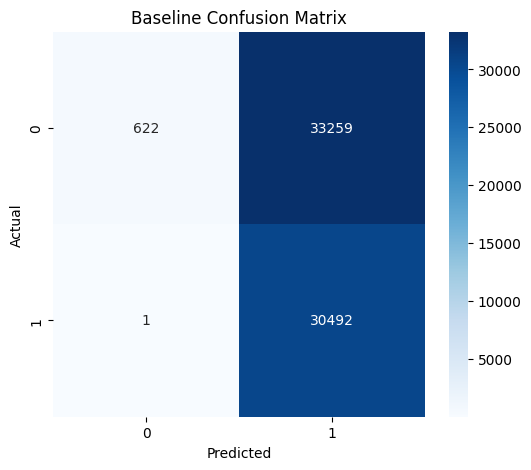

In [25]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, baseline_predictions)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Baseline Confusion Matrix")
plt.show()

In [26]:
from sklearn.ensemble import RandomForestClassifier

optimized_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=5,
        random_state=42
    ))
])

optimized_model.fit(X_train, y_train)

optimized_predictions = optimized_model.predict(X_test)

print("Optimized model trained successfully!")

Optimized model trained successfully!


In [27]:
print("Accuracy :", accuracy_score(y_test, optimized_predictions))
print("Precision:", precision_score(y_test, optimized_predictions, average="weighted"))
print("Recall   :", recall_score(y_test, optimized_predictions, average="weighted"))
print("F1 Score :", f1_score(y_test, optimized_predictions, average="weighted"))

print("\nClassification Report\n")
print(classification_report(y_test, optimized_predictions))

Accuracy : 0.49272998415509367
Precision: 0.7529183114028413
Recall   : 0.49272998415509367
F1 Score : 0.3453805108924825

Classification Report

              precision    recall  f1-score   support

           0       1.00      0.04      0.07     33881
           1       0.48      1.00      0.65     30493

    accuracy                           0.49     64374
   macro avg       0.74      0.52      0.36     64374
weighted avg       0.75      0.49      0.35     64374



In [28]:
import pandas as pd

comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Baseline": [
        accuracy_score(y_test, baseline_predictions),
        precision_score(y_test, baseline_predictions, average="weighted"),
        recall_score(y_test, baseline_predictions, average="weighted"),
        f1_score(y_test, baseline_predictions, average="weighted")
    ],
    "Optimized": [
        accuracy_score(y_test, optimized_predictions),
        precision_score(y_test, optimized_predictions, average="weighted"),
        recall_score(y_test, optimized_predictions, average="weighted"),
        f1_score(y_test, optimized_predictions, average="weighted")
    ]
})

comparison

,Metric,Baseline,Optimized
0,Accuracy,0.483332,0.492730
1,Precision,0.752033,0.752918
2,Recall,0.483332,0.492730
3,F1 Score,0.325491,0.345381


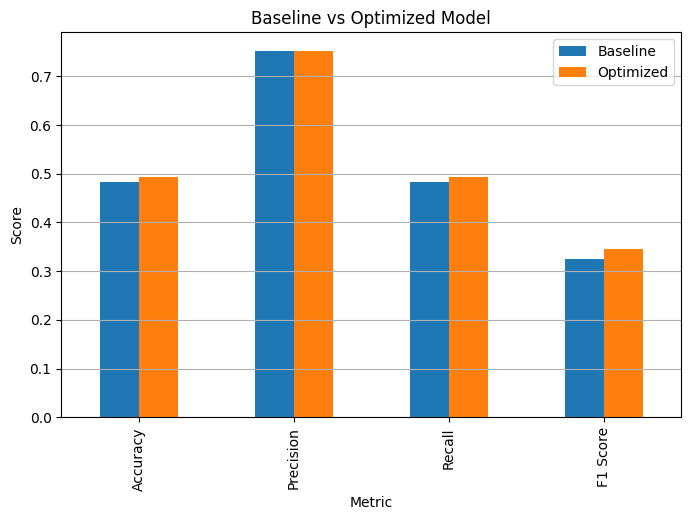

In [29]:
comparison.set_index("Metric").plot(kind="bar", figsize=(8,5))

plt.title("Baseline vs Optimized Model")
plt.ylabel("Score")
plt.grid(axis="y")

plt.show()

In [30]:
rf = optimized_model.named_steps["classifier"]

feature_names = optimized_model.named_steps["preprocessor"].get_feature_names_out()

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values("Importance", ascending=False)

importance.head(10)

,Feature,Importance
0,num__CustomerID,0.182061
4,num__Support Calls,0.173518
6,num__Total Spend,0.142554
1,num__Age,0.140018
5,num__Payment Delay,0.114499
14,cat__Contract Length_Monthly,0.062126
7,num__Last Interaction,0.060145
8,cat__Gender_Female,0.033434
9,cat__Gender_Male,0.027678
2,num__Tenure,0.017006


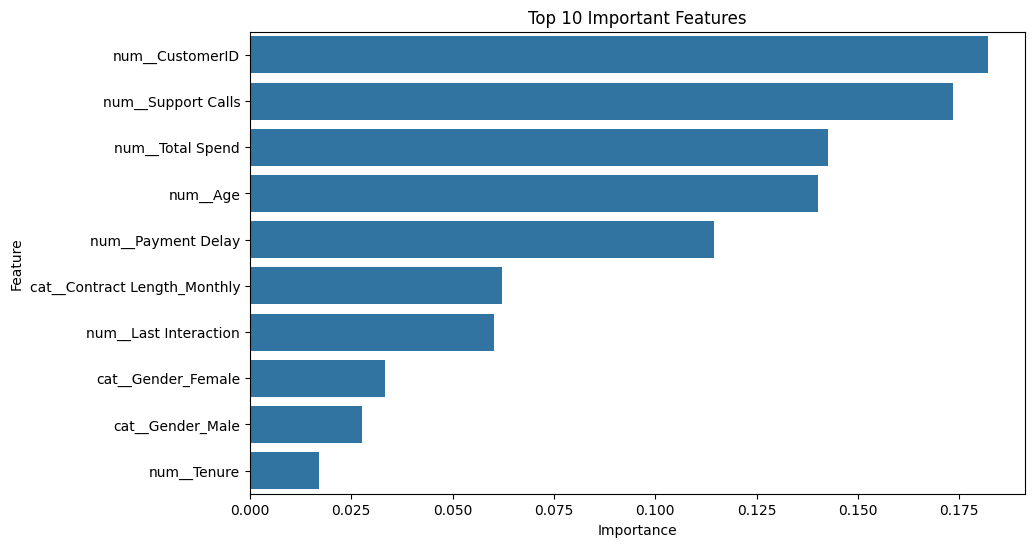

In [31]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")
plt.show()